# Joint Distributions

ProbPipe provides several joint distribution types for modeling multiple related quantities:

| Type | Use Case | Key Feature |
|------|----------|-------------|
| `ProductDistribution` | Independent named components | `log_prob` = sum of marginals |
| `SequentialJointDistribution` | Autoregressive dependence | Callables receive earlier samples |
| `JointEmpirical` | MCMC / importance samples | Joint row resampling preserves correlation |
| `JointGaussian` | Analytical Gaussian models | Exact conditioning via `condition_on()` |

All joint distributions inherit from `PyTreeArrayDistribution` and return **pytrees** (dicts) from `sample()`.
Components can be organized as **flat dicts** or **nested dicts** — the API works identically either way.

This tutorial walks through the flat-dict API first, then shows how nested dicts generalize it.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from probpipe import (
    Normal,
    Gamma,
    MultivariateNormal,
    ProductDistribution,
    SequentialJointDistribution,
    JointEmpirical,
    JointGaussian,
    DistributionView,
    EmpiricalDistribution,
    FlattenedView,
)
from probpipe.core.node import WorkflowFunction
from probpipe.provenance import provenance_ancestors

---
## Part 1: Flat Dict — ProductDistribution

The simplest joint distribution is a `ProductDistribution` with flat keyword arguments.
Each keyword becomes a component name, and the corresponding value is an `ArrayDistribution`.

### Construction and Introspection

In [2]:
joint = ProductDistribution(
    theta=Normal(loc=0.0, scale=1.0),
    sigma=Normal(loc=1.0, scale=0.5),
)
print(f"Joint: {joint}")
print(f"Components: {joint.component_names}")
print(f"Event shapes: {joint.event_shapes}")
print(f"Event size: {joint.event_size}")
print(f"Mean: {joint.mean()}")
print(f"Variance: {joint.variance()}")

Joint: ProductDistribution(theta=Normal, sigma=Normal)
Components: ('theta', 'sigma')
Event shapes: {'sigma': (), 'theta': ()}
Event size: 2
Mean: {'sigma': Array(1., dtype=float32), 'theta': Array(0., dtype=float32)}
Variance: {'sigma': Array(0.25, dtype=float32), 'theta': Array(1., dtype=float32)}


### Sampling

`sample()` returns a dict of per-component arrays. Each value has shape
`(*sample_shape, *batch_shape, *component_event_shape)`.

In [3]:
samples = joint.sample(sample_shape=(5,))
print(f"Sample keys: {list(samples.keys())}")
print(f"theta samples: {samples['theta']}")
print(f"sigma samples: {samples['sigma']}")

Sample keys: ['sigma', 'theta']
theta samples: [-2.4424558  -2.0356805   0.20554423 -0.3535502  -0.76197404]
sigma samples: [1.5020071  0.54683137 0.62591386 0.41431653 0.5643836 ]


W0324 14:44:48.086670 6770932 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


### Accessing Components

`joint['name']` returns a `DistributionView` — a lightweight `ArrayDistribution`
that remembers its parent joint. When sampled standalone, it draws a full joint
sample and extracts the requested component.

In [4]:
view_theta = joint['theta']
print(f"View: {view_theta}")
print(f"Event shape: {view_theta.event_shape}")
print(f"Mean: {float(view_theta.mean()):.3f}")
s = view_theta.sample(sample_shape=(5,))
print(f"Samples: {s}")

View: DistributionView(parent=ProductDistribution, path='theta')
Event shape: ()
Mean: 0.000
Samples: [-0.24392003  0.12287012 -0.7633101  -0.9311066   1.183018  ]


### Correlated Broadcasting

When two `DistributionView` instances from the **same parent** are passed to a
`WorkflowFunction`, the parent is sampled **once** and each view extracts its
component. This preserves correlation. Compare the two cases below: jointly
sampled views yield `a - b ≈ 0` (since both come from the same sample), while
independent distributions do not.

In [5]:
def difference(a, b):
    return a - b

w = WorkflowFunction(func=difference, n_broadcast_samples=200, vectorize='loop', seed=0)

# Jointly sampled: both come from the same parent → a - b ≈ 0
result_joint = w(**joint.bind(a='theta', b='theta'))
print(f"Joint std:  {float(jnp.std(result_joint.samples)):.4f}  (≈ 0)")

# Independent: different distributions → a - b has nonzero variance
result_indep = w(a=Normal(0, 1), b=Normal(0, 1))
print(f"Indep std:  {float(jnp.std(result_indep.samples)):.4f}  (≈ √2)")

Joint std:  0.0000  (≈ 0)
Indep std:  1.4775  (≈ √2)


### Log-Probability

`log_prob()` accepts a dict with the same structure as the components.
For a `ProductDistribution`, it equals the sum of per-component log-probs.

In [6]:
x = {"theta": jnp.array(0.5), "sigma": jnp.array(1.5)}
lp_joint = joint.log_prob(x)
lp_sum = joint.components['theta'].log_prob(0.5) + joint.components['sigma'].log_prob(1.5)
print(f"Joint log_prob: {float(lp_joint):.4f}")
print(f"Sum of marginals: {float(lp_sum):.4f}")
print(f"Equal: {bool(jnp.isclose(lp_joint, lp_sum))}")

Joint log_prob: -1.7697
Sum of marginals: -1.7697


Equal: True


`component_log_prob()` returns the per-component contributions as a dict:

In [7]:
clp = joint.component_log_prob(x)
print(f"Component log-probs: {clp}")
print(f"Sum: {float(clp['theta'] + clp['sigma']):.4f}")

Component log-probs: {'sigma': Array(-0.72579134, dtype=float32), 'theta': Array(-1.0439385, dtype=float32)}
Sum: -1.7697


### Conditioning

`condition_on()` returns a new joint distribution over the remaining
(unconditioned) components.

In [8]:
conditioned = joint.condition_on(theta=jnp.array(2.0))
print(f"Original components: {joint.component_names}")
print(f"After conditioning on theta=2.0: {conditioned.component_names}")
print(f"Event shapes: {conditioned.event_shapes}")

s_cond = conditioned.sample(sample_shape=(5,))
print(f"\nKeys: {list(s_cond.keys())}")
print(f"Sigma samples: {s_cond['sigma']}")

Original components: ('theta', 'sigma')
After conditioning on theta=2.0: ('sigma',)
Event shapes: {'sigma': ()}

Keys: ['sigma']
Sigma samples: [1.1742839  1.1830198  0.33859354 1.3373926  1.115743  ]


### Flat-Vector Interop

`flatten_value()` concatenates all component arrays into a single flat vector.
`unflatten_value()` reverses this. `as_flat_distribution()` returns a
`FlattenedView` wrapping the joint as a flat `ArrayDistribution`.

In [9]:
s = joint.sample(sample_shape=(3,))
flat = joint.flatten_value(s)
print(f"Flat shape: {flat.shape}")
print(f"Flat:\n{flat}")

recovered = joint.unflatten_value(flat)
print(f"\nRecovered theta: {recovered['theta']}")
print(f"Recovered sigma: {recovered['sigma']}")

# FlattenedView for algorithms expecting flat vectors
flat_dist = joint.as_flat_distribution()
print(f"\nFlattenedView event_shape: {flat_dist.event_shape}")
print(f"FlattenedView sample: {flat_dist.sample(sample_shape=(2,))}")

Flat shape: (3, 2)
Flat:
[[-0.18916988 -1.9432216 ]
 [ 0.14691663  0.1048161 ]
 [ 0.7543018  -0.04758957]]

Recovered theta: [-1.9432216   0.1048161  -0.04758957]
Recovered sigma: [-0.18916988  0.14691663  0.7543018 ]

FlattenedView event_shape: (2,)


FlattenedView sample: [[1.0588326  0.3526764 ]
 [1.4438868  0.20065445]]


### Multivariate Components

`ProductDistribution` works with multivariate components. The total
`event_size` is the sum of all component event sizes.

Event shapes: {'pos': (2,), 'vel': (2,)}
Event size: 4


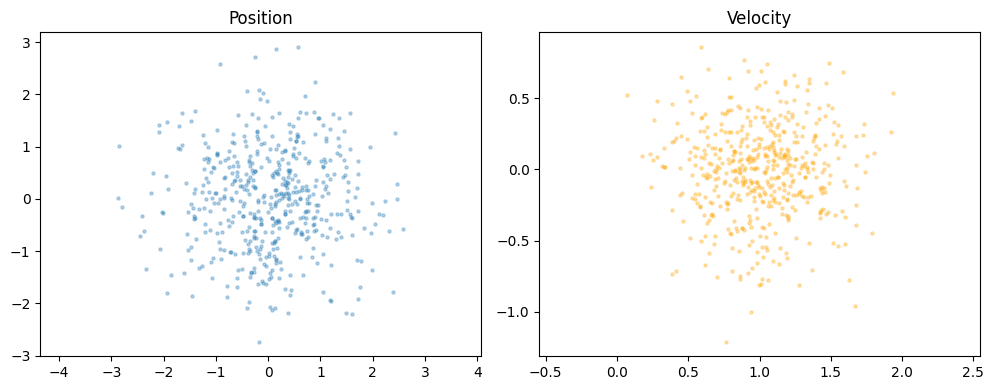

In [10]:
joint_mv = ProductDistribution(
    pos=MultivariateNormal(loc=jnp.zeros(2), cov=jnp.eye(2)),
    vel=MultivariateNormal(loc=jnp.array([1.0, 0.0]), cov=0.1 * jnp.eye(2)),
)
print(f"Event shapes: {joint_mv.event_shapes}")
print(f"Event size: {joint_mv.event_size}")

ss = joint_mv.sample(sample_shape=(500,))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(ss['pos'][:, 0], ss['pos'][:, 1], alpha=0.3, s=5)
ax1.set_title("Position"); ax1.axis("equal")
ax2.scatter(ss['vel'][:, 0], ss['vel'][:, 1], alpha=0.3, s=5, color="orange")
ax2.set_title("Velocity"); ax2.axis("equal")
plt.tight_layout(); plt.show()

---
## Part 2: Nested Dict — Grouped Components

Components can be organized into **nested dicts** for logical grouping.
The nesting is purely organizational — all leaf components remain
statistically independent. The entire API generalizes seamlessly:
samples, `event_shapes`, `log_prob`, etc. all mirror the nested structure.

In [11]:
nested = ProductDistribution(
    physics={"force": Normal(loc=0.0, scale=1.0),
             "mass": Gamma(concentration=2.0, rate=1.0)},
    observation=Normal(loc=0.0, scale=0.1),
)
print(f"Joint: {nested}")
print(f"Event shapes: {nested.event_shapes}")
print(f"Event size: {nested.event_size}")
print(f"Component names (key paths): {nested.component_names}")

Joint: ProductDistribution({'observation': 'Normal', 'physics': {'force': 'Normal', 'mass': 'Gamma'}})
Event shapes: {'observation': (), 'physics': {'force': (), 'mass': ()}}
Event size: 3
Component names (key paths): (('observation',), ('physics', 'force'), ('physics', 'mass'))


### Nested Sampling

Samples mirror the nested dict structure:

In [12]:
s = nested.sample(sample_shape=(3,))
print(f"Top-level keys: {list(s.keys())}")
print(f"physics sub-keys: {list(s['physics'].keys())}")
print(f"\nforce samples:       {s['physics']['force']}")
print(f"mass samples:        {s['physics']['mass']}")
print(f"observation samples: {s['observation']}")

Top-level keys: ['observation', 'physics']
physics sub-keys: ['force', 'mass']

force samples:       [-8.6731231e-01  2.0302141e-03 -2.0332427e+00]
mass samples:        [0.9371058 4.0422387 1.9964874]
observation samples: [ 0.05327168 -0.15669219 -0.04170815]


### Nested Log-Prob and Moments

`log_prob()` accepts the same nested structure. `mean()` and `variance()`
return nested dicts. `component_log_prob()` returns per-leaf contributions.

In [13]:
s = nested.sample()
print(f"log_prob: {float(nested.log_prob(s)):.4f}")
print(f"\nComponent log-probs: {nested.component_log_prob(s)}")
print(f"\nMean: {nested.mean()}")
print(f"Variance: {nested.variance()}")

log_prob: -2.9276

Component log-probs: {'observation': Array(0.76309603, dtype=float32), 'physics': {'force': Array(-1.0220572, dtype=float32), 'mass': Array(-2.66859, dtype=float32)}}

Mean: {'observation': Array(0., dtype=float32), 'physics': {'force': Array(0., dtype=float32), 'mass': Array(2., dtype=float32)}}
Variance: {'observation': Array(0.01, dtype=float32), 'physics': {'force': Array(1., dtype=float32), 'mass': Array(2., dtype=float32)}}


### Accessing Nested Leaves

Use a **key-path tuple** to reach a nested leaf. For top-level leaves,
a plain string still works.

In [14]:
# Nested leaf: use a tuple of strings
view_force = nested["physics", "force"]
print(f"Force view: {view_force}")
print(f"Force event_shape: {view_force.event_shape}")
print(f"Force samples: {view_force.sample(sample_shape=(5,))}")

# Top-level leaf: plain string
view_obs = nested["observation"]
print(f"\nObservation view: {view_obs}")
print(f"Observation samples: {view_obs.sample(sample_shape=(5,))}")

Force view: DistributionView(parent=ProductDistribution, path='physics > force')
Force event_shape: ()


Force samples: [ 2.1392777   0.26040107  0.41371214 -0.59678113 -1.7995216 ]

Observation view: DistributionView(parent=ProductDistribution, path='observation')


Observation samples: [ 0.01048912  0.10064474  0.20076834 -0.0379463   0.13757448]


### Accessing Internal Nodes (Sub-Joints)

When a key path resolves to an **internal dict node** (not a leaf),
`__getitem__` returns a new `ProductDistribution` wrapping that sub-tree.
This is the **marginal** distribution over that group's components.

In [15]:
# Indexing an internal node returns a sub-joint
sub_physics = nested["physics"]
print(f"Type: {type(sub_physics).__name__}")
print(f"Components: {sub_physics.component_names}")
print(f"Event shapes: {sub_physics.event_shapes}")
print(f"Event size: {sub_physics.event_size}")

# The sub-joint samples and computes log-prob like any ProductDistribution
s = sub_physics.sample(sample_shape=(3,))
print(f"\nSample keys: {list(s.keys())}")
print(f"Force samples: {s['force']}")
print(f"Mass samples:  {s['mass']}")
print(f"Log-prob: {sub_physics.log_prob(sub_physics.sample())}")
print(f"Mean: {sub_physics.mean()}")

Type: ProductDistribution
Components: ('force', 'mass')
Event shapes: {'force': (), 'mass': ()}
Event size: 2



Sample keys: ['force', 'mass']
Force samples: [1.1219075  0.55665874 1.1072611 ]
Mass samples:  [0.7079296 1.758048  2.5699596]
Log-prob: -1.9919791221618652
Mean: {'force': Array(0., dtype=float32), 'mass': Array(2., dtype=float32)}


### Nested Broadcasting

Views from nested joints work in `WorkflowFunction` broadcasting just like
flat views — correlated components from the same parent are sampled jointly.

In [16]:
def scale_force(force, mass):
    """Newton's F = m*a  →  a = force / mass"""
    return force / mass

wf = WorkflowFunction(func=scale_force, n_broadcast_samples=200, vectorize='loop', seed=1)
result = wf(
    force=nested["physics", "force"],
    mass=nested["physics", "mass"],
)
print(f"Result type: {type(result).__name__}")
print(f"Acceleration mean: {float(jnp.mean(result.samples)):.3f}")
print(f"Acceleration std:  {float(jnp.std(result.samples)):.3f}")

Result type: EmpiricalDistribution
Acceleration mean: -0.096
Acceleration std:  1.167


### Nested Flatten / Unflatten

`flatten_value()` and `unflatten_value()` work on nested structures,
flattening all leaves into a single vector and reconstructing the
nested dict on the way back.

In [17]:
s = nested.sample(sample_shape=(4,))
flat = nested.flatten_value(s)
print(f"Flat shape: {flat.shape}  (3 scalar leaves → event_size=3)")

recovered = nested.unflatten_value(flat)
print(f"Recovered physics.force: {recovered['physics']['force']}")
print(f"Recovered observation:   {recovered['observation']}")

# Verify roundtrip
for orig, rec in zip(jax.tree.leaves(s), jax.tree.leaves(recovered)):
    assert jnp.allclose(orig, rec)
print("\n✓ Roundtrip verified")

Flat shape: (4, 3)  (3 scalar leaves → event_size=3)
Recovered physics.force: [-0.19068323 -1.2561195  -0.12966277 -0.5372527 ]
Recovered observation:   [-0.16654015  0.08289426 -0.12889524  0.07624753]

✓ Roundtrip verified


### Conditioning on Nested Components

`condition_on()` currently works on **top-level** keys. To condition on
an entire nested group, pass the matching sub-dict:

In [18]:
# Remove the physics group entirely
cond = nested.condition_on(
    physics={"force": jnp.array(1.0), "mass": jnp.array(2.0)}
)
print(f"Remaining components: {tuple(cond._components.keys())}")
print(f"Event size: {cond.event_size}")
print(f"Sample: {cond.sample()}")

# Remove just the observation
cond2 = nested.condition_on(observation=jnp.array(0.5))
print(f"\nRemaining components: {tuple(cond2._components.keys())}")
print(f"Event size: {cond2.event_size}")
print(f"Sample: {cond2.sample()}")

Remaining components: ('observation',)
Event size: 1
Sample: {'observation': Array(0.00522427, dtype=float32)}

Remaining components: ('physics',)
Event size: 2


Sample: {'physics': {'force': Array(-0.65401435, dtype=float32), 'mass': Array(0.97185165, dtype=float32)}}


---
## Part 3: SequentialJointDistribution

`SequentialJointDistribution` models autoregressive dependence: later
components can be callables that receive earlier samples and return
distributions.

> **Note:** Sequential joints support flat dicts only (no nesting),
> because dependencies are expressed via function parameter names.

In [19]:
seq = SequentialJointDistribution(
    z=Normal(loc=0.0, scale=1.0),
    x=lambda z: Normal(loc=z, scale=0.5),        # x | z ~ N(z, 0.5)
    y=lambda z, x: Normal(loc=z + x, scale=0.1), # y | z,x ~ N(z+x, 0.1)
)
print(f"Components: {seq.component_names}")
print(f"Event shapes: {seq.event_shapes}")

Components: ('z', 'x', 'y')
Event shapes: {'x': (), 'y': (), 'z': ()}


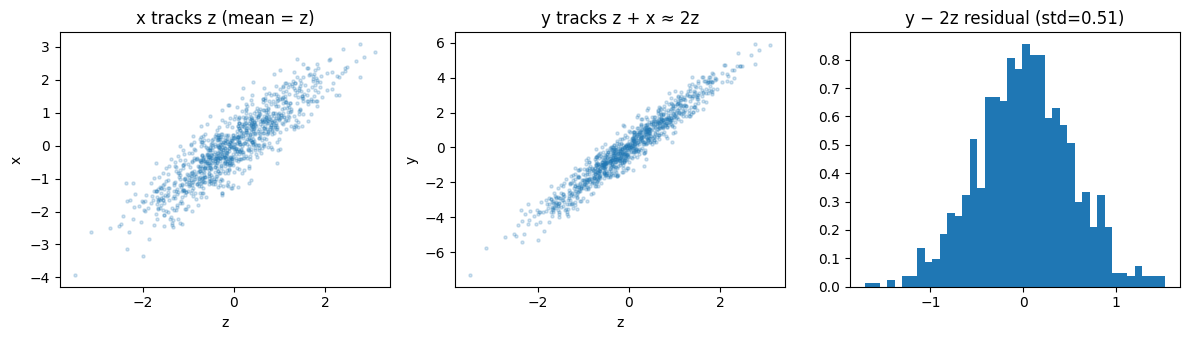

In [20]:
ss = seq.sample(sample_shape=(1000,))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].scatter(ss['z'], ss['x'], alpha=0.2, s=5)
axes[0].set_xlabel('z'); axes[0].set_ylabel('x')
axes[0].set_title('x tracks z (mean = z)')

axes[1].scatter(ss['z'], ss['y'], alpha=0.2, s=5)
axes[1].set_xlabel('z'); axes[1].set_ylabel('y')
axes[1].set_title('y tracks z + x ≈ 2z')

residual = ss['y'] - 2 * ss['z']
axes[2].hist(np.array(residual), bins=40, density=True)
axes[2].set_title(f'y − 2z residual (std={float(jnp.std(residual)):.2f})')
plt.tight_layout(); plt.show()

### Conditioning in Sequential Models

Conditioning on a **root** component is always sampleable. Conditioning
on a non-root whose parents are unconditioned raises `NotImplementedError`
at sample time (because forward sampling would use the prior, not the
posterior for those parents). `unnormalized_log_prob()` is always available.

In [21]:
# Case 1: Condition on root z=2.0 — always works
cond_root = seq.condition_on(z=jnp.array(2.0))
s = cond_root.sample(sample_shape=(500,))
print(f"x|z=2 mean: {float(jnp.mean(s['x'])):.2f}  (expected ≈ 2.0)")
print(f"y|z=2 mean: {float(jnp.mean(s['y'])):.2f}  (expected ≈ 4.0)")

# Case 2: Condition on non-root x — NOT sampleable
cond_nonroot = seq.condition_on(x=jnp.array(1.0))
try:
    cond_nonroot.sample(sample_shape=(5,))
except NotImplementedError as e:
    print(f"\nCondition on non-root: NotImplementedError")

# Case 3: Condition on non-root AND all its parents — sampleable
cond_both = seq.condition_on(z=jnp.array(1.0), x=jnp.array(2.0))
s = cond_both.sample(sample_shape=(100,))
print(f"\ny|z=1,x=2 mean: {float(jnp.mean(s['y'])):.2f}  (expected ≈ 3.0)")

x|z=2 mean: 1.97  (expected ≈ 2.0)
y|z=2 mean: 3.97  (expected ≈ 4.0)

Condition on non-root: NotImplementedError



y|z=1,x=2 mean: 3.00  (expected ≈ 3.0)


---
## Part 4: JointEmpirical

`JointEmpirical` stores per-component sample arrays (all with the same
number of rows) and resamples rows **jointly**, preserving correlation.

> **Note:** `JointEmpirical` supports flat dicts only.

Components: ('z', 'x'), n=500


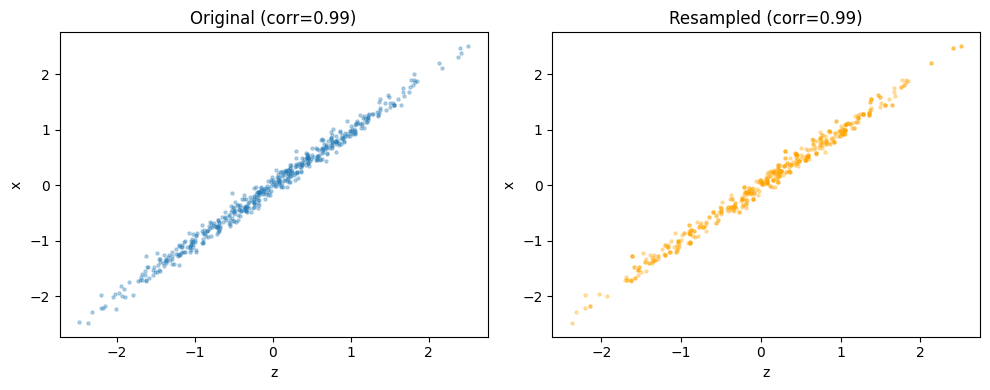

In [22]:
key = jax.random.PRNGKey(42)
n_samples = 500
z_samples = jax.random.normal(key, (n_samples,))
x_samples = z_samples + 0.1 * jax.random.normal(jax.random.PRNGKey(43), (n_samples,))

je = JointEmpirical(z=z_samples, x=x_samples)
print(f"Components: {je.component_names}, n={je.n}")

resampled = je.sample(sample_shape=(500,))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(np.array(z_samples), np.array(x_samples), alpha=0.3, s=5)
ax1.set_title(f'Original (corr={float(jnp.corrcoef(z_samples, x_samples)[0,1]):.2f})')
ax1.set_xlabel('z'); ax1.set_ylabel('x')
ax2.scatter(np.array(resampled['z']), np.array(resampled['x']), alpha=0.3, s=5, color='orange')
ax2.set_title(f'Resampled (corr={float(jnp.corrcoef(resampled["z"], resampled["x"])[0,1]):.2f})')
ax2.set_xlabel('z'); ax2.set_ylabel('x')
plt.tight_layout(); plt.show()

### Weighted Samples

In [23]:
je_w = JointEmpirical(
    x=jnp.array([0.0, 1.0, 2.0, 3.0]),
    y=jnp.array([10.0, 20.0, 30.0, 40.0]),
    weights=jnp.array([0.01, 0.01, 0.08, 0.90]),
)
ws = je_w.sample(sample_shape=(1000,))
print(f"Resampled x mean: {float(jnp.mean(ws['x'])):.2f}  (expected ≈ 2.9)")
print(f"Resampled y mean: {float(jnp.mean(ws['y'])):.2f}  (expected ≈ 39)")

Resampled x mean: 2.87  (expected ≈ 2.9)
Resampled y mean: 38.66  (expected ≈ 39)


---
## Part 5: JointGaussian

`JointGaussian` wraps a multivariate Gaussian with named components and
cross-covariance, supporting exact analytical conditioning.

> **Note:** `JointGaussian` supports flat dicts only. Component dimensions
> are specified as integer keyword arguments.

In [24]:
cov = jnp.array([[1.0, 0.8],
                 [0.8, 1.0]])
jg = JointGaussian(mean=jnp.array([0.0, 0.0]), cov=cov, x=1, y=1)
print(f"Components: {jg.component_names}")
print(f"Event shapes: {jg.event_shapes}")
print(f"Covariance:\n{jg.covariance}")

Components: ('x', 'y')
Event shapes: {'x': (1,), 'y': (1,)}
Covariance:
[[1.  0.8]
 [0.8 1. ]]


### Exact Conditioning

`condition_on()` applies the standard Gaussian conditioning formulas.
The result is a new `JointGaussian` over the remaining components.

In [25]:
cond = jg.condition_on(x=jnp.array([2.0]))
print(f"Remaining: {cond.component_names}")
# μ_y|x=2 = 0 + 0.8 * 1.0 * (2 - 0) = 1.6
# σ²_y|x  = 1 - 0.8² = 0.36
print(f"Conditional mean:     {float(cond.mean()['y'][0]):.4f}  (expected 1.6)")
print(f"Conditional variance: {float(cond.variance()['y'][0]):.4f}  (expected 0.36)")

Remaining: ('y',)
Conditional mean:     1.6000  (expected 1.6)
Conditional variance: 0.3600  (expected 0.36)


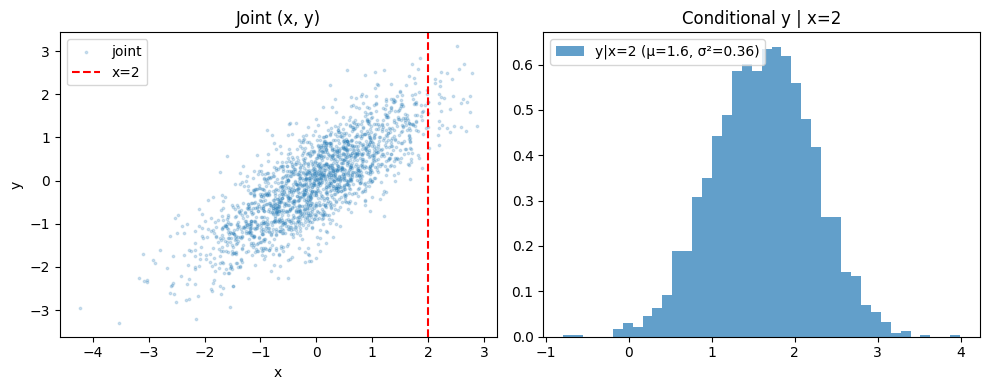

In [26]:
jg_samples = jg.sample(sample_shape=(2000,))
cond_samples = cond.sample(sample_shape=(2000,))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(np.array(jg_samples['x'].ravel()), np.array(jg_samples['y'].ravel()),
            alpha=0.2, s=3, label='joint')
ax1.axvline(2.0, color='red', linestyle='--', label='x=2')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title('Joint (x, y)'); ax1.legend()

ax2.hist(np.array(cond_samples['y'].ravel()), bins=40, density=True, alpha=0.7,
         label=f"y|x=2 (μ={float(cond.mean()['y'][0]):.1f}, σ²={float(cond.variance()['y'][0]):.2f})")
ax2.set_title('Conditional y | x=2'); ax2.legend()
plt.tight_layout(); plt.show()

---
## Provenance Tracking

Every `condition_on()` call records which joint distribution was conditioned,
what was observed, and the full operation chain.

In [27]:
cond_y = jg.condition_on(x=jnp.array([2.0]))
print(f"Operation: {cond_y.source.operation}")
print(f"Conditioned: {cond_y.source.metadata['conditioned']}")
print(f"Parent type: {type(cond_y.source.parents[0]).__name__}")

# Chain of conditioning on a SequentialJointDistribution
step1 = seq.condition_on(x=jnp.array(1.5))
step2 = step1.condition_on(z=jnp.array(0.5))
ancestors = provenance_ancestors(step2)
print(f"\nAncestors: {[type(a).__name__ for a in ancestors]}")

Operation: condition_on
Conditioned: ['x']
Parent type: JointGaussian

Ancestors: ['SequentialJointDistribution', 'SequentialJointDistribution']


---
## Summary

| Feature | Flat Dict | Nested Dict |
|---------|-----------|-------------|
| `sample()` | `{"x": array, "y": array}` | `{"group": {"a": array}, "b": array}` |
| `event_shapes` | `{"x": (), "y": (3,)}` | `{"group": {"a": ()}, "b": (3,)}` |
| `component_names` | `("x", "y")` | `(("b",), ("group", "a"))` |
| `joint[key]` | `joint["x"]` | `joint["group", "a"]` |
| `flatten_value` / `unflatten_value` | ✓ | ✓ |
| `as_flat_distribution()` | ✓ | ✓ |
| `condition_on()` | `condition_on(x=val)` | `condition_on(group={"a": val})` |
| `log_prob()` | accepts flat dict | accepts nested dict |

All joint types share:
- **`joint[key]`** → `DistributionView` for correlated broadcasting
- **`sample()`** → pytree (dict) of per-component arrays
- **`condition_on()`** → distribution over remaining components
- **`flatten_value()` / `as_flat_distribution()`** → flat-vector interop
- **`bind()`** → remap component names to workflow arguments

Nested dict support is available in `ProductDistribution` and the base
`JointDistribution`. `SequentialJointDistribution`, `JointEmpirical`,
and `JointGaussian` are flat-dict only.